# Walk-forward GMM — OOS from 1990 (pmr_paper)

Expanding `StandardScaler` + dual Hungarian (temporal + economic). **No** EWZ scaling, **no** soft-crisis templates.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def _find_pmr_root() -> Path:
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError("Run from inside pmr_paper/")

PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.paths import FIGURES_DIR, OUTPUT_DIR, load_features
from scripts.gmm_pipeline import fit_static_gmm, run_walk_forward, static_regime_table
from scripts.plots import plot_regime_history, plot_walk_forward_subset
from scripts.regime_labeling import map_clusters, print_score_diagnostics, sanity_check

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
features = load_features()
print(f"Loaded {features.shape[0]} months x {features.shape[1]} features")


Matplotlib is building the font cache; this may take a moment.


Loaded 663 months x 17 features


## K = 4

Walk-forward GMM K=4: 100%|██████████| 437/437 [02:19<00:00,  3.13it/s]



  SANITY CHECK (K=4)
  Oil Crisis / Stagflation        SKIPPED
  Volcker era                     SKIPPED
  Black Monday                    SKIPPED
  [PASS] GFC                             want         Crisis >= 30%  |  got 40%  (Crisis:8, Inflation:6, Steady State:1, Walking on Ice:5)
  [FAIL] COVID crash                     want         Crisis >= 33%  |  got 0%  (Steady State:1, Walking on Ice:1)
  [PASS] Dot-com / late 90s              want   Steady State >= 30%  |  got 90%  (Inflation:1, Steady State:53, Walking on Ice:5)
  [PASS] Post-GFC expansion              want   Steady State >= 40%  |  got 67%  (Crisis:11, Inflation:1, Steady State:64, Walking on Ice:19)
  Result: SOME CHECKS FAILED


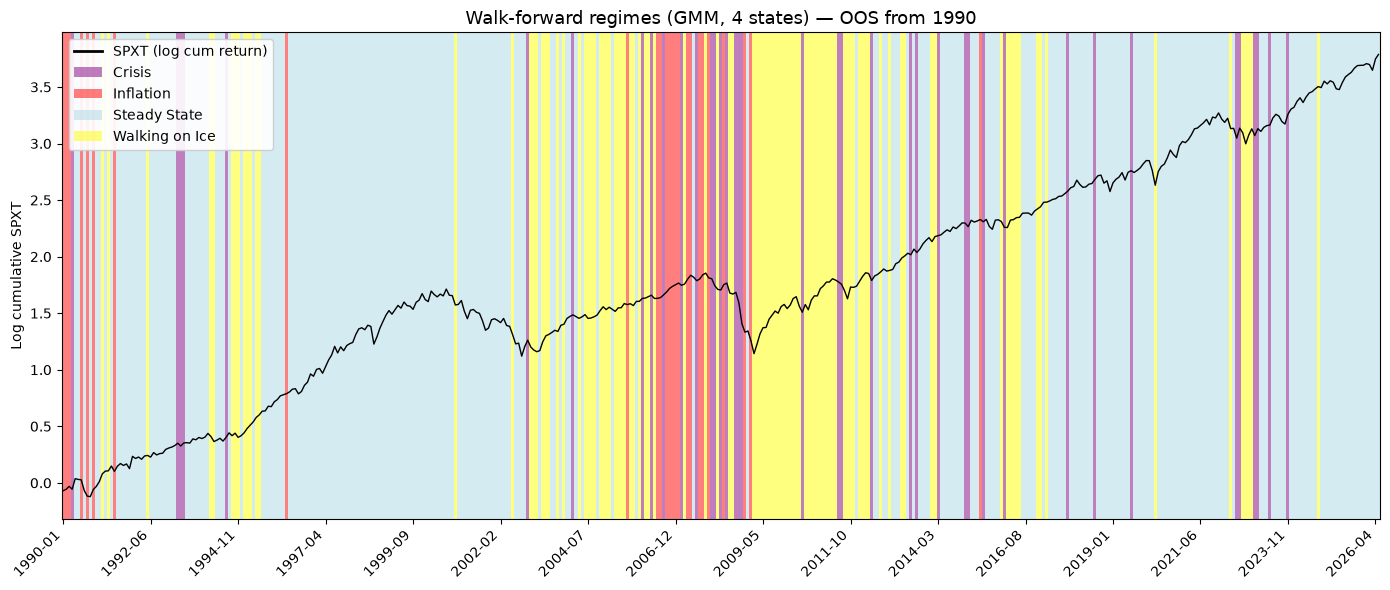

,Prob_Regime0,Prob_Regime1,Prob_Regime2,Prob_Regime3,Regime_Candidate,Regime,Regime_Name
2026-01-31,0.000003,4.447733e-15,0.994664,0.005332,2,2,Steady State
2026-02-28,0.000468,2.223853e-15,0.998777,0.000754,2,2,Steady State
2026-03-31,0.000085,1.111927e-15,0.999538,0.000377,2,2,Steady State
2026-04-30,0.000033,5.559634e-16,0.838283,0.161684,2,2,Steady State
2026-05-31,0.000016,2.779817e-16,0.979702,0.020281,2,2,Steady State


In [2]:
wf4 = run_walk_forward(features, k=4, show_progress=True)
wf4.to_csv(OUTPUT_DIR / "walk_forward_k4.csv")
plot_walk_forward_subset(
    features, wf4, k=4,
    title="Walk-forward regimes (GMM, 4 states) — OOS from 1990",
    save_path=FIGURES_DIR / "walk_forward_k4.png",
)
wf4.tail()


## K = 5

Walk-forward GMM K=5: 100%|██████████| 437/437 [00:36<00:00, 12.01it/s]



  SANITY CHECK (K=5)
  Oil Crisis / Stagflation        SKIPPED
  Volcker era                     SKIPPED
  Black Monday                    SKIPPED
  [PASS] GFC                             want         Crisis >= 30%  |  got 80%  (Crisis:16, Steady State:4)
  [PASS] COVID crash                     want         Crisis >= 33%  |  got 100%  (Crisis:2)
  [FAIL] Dot-com / late 90s              want    Bull Market >= 30%  |  got 10%  (Crisis:4, Steady State:49, Bull Market:6)
  [FAIL] Post-GFC expansion              want   Steady State >= 35%  |  got 13%  (Crisis:6, Inflation:12, Steady State:12, Walking on Ice:7, Bull Market:58)
  Result: SOME CHECKS FAILED


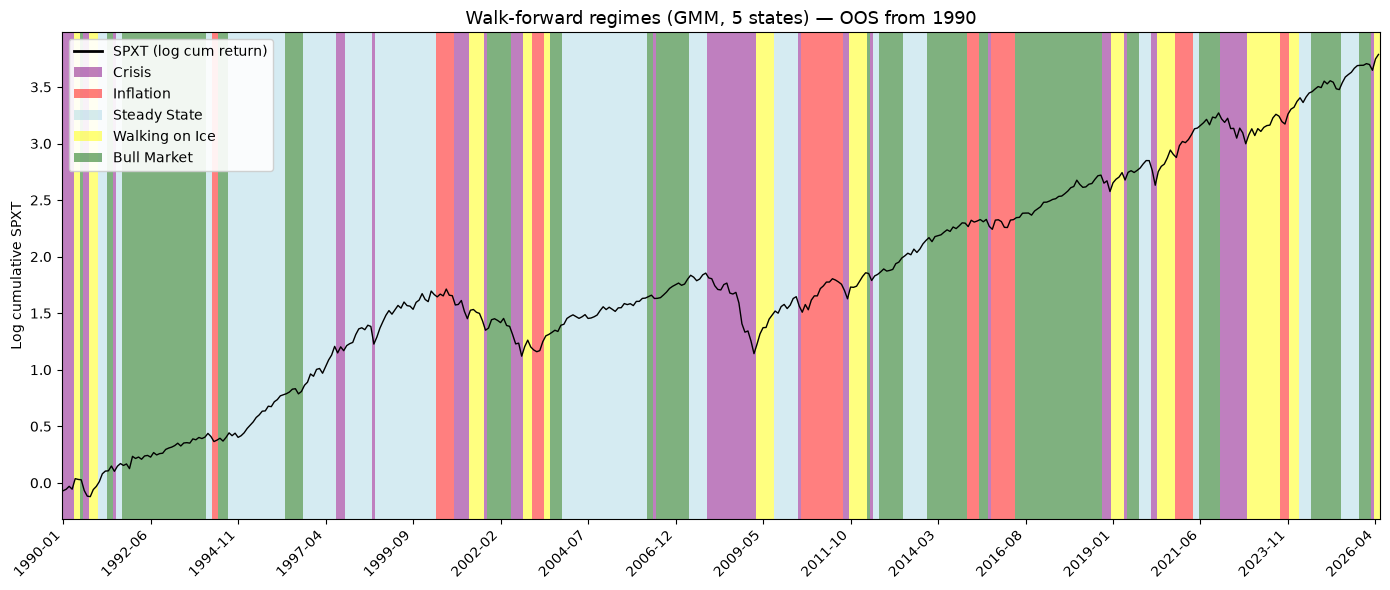

,Prob_Regime0,Prob_Regime1,Prob_Regime2,Prob_Regime3,Prob_Regime4,Regime_Candidate,Regime,Regime_Name
2026-01-31,0.000003,0.014635,0.157291,0.000315,0.827755,4,4,Bull Market
2026-02-28,0.000002,0.010979,0.653854,0.000236,0.334929,2,4,Bull Market
2026-03-31,0.565001,0.008233,0.185440,0.000177,0.241149,0,0,Crisis
2026-04-30,0.108751,0.006175,0.139080,0.565133,0.180862,3,3,Walking on Ice
2026-05-31,0.081563,0.004631,0.628313,0.108870,0.176622,2,3,Walking on Ice


In [3]:
wf5 = run_walk_forward(features, k=5, show_progress=True)
wf5.to_csv(OUTPUT_DIR / "walk_forward_k5.csv")
plot_walk_forward_subset(
    features, wf5, k=5,
    title="Walk-forward regimes (GMM, 5 states) — OOS from 1990",
    save_path=FIGURES_DIR / "walk_forward_k5.png",
)
wf5.tail()
